In [1]:
!pip install apyori


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from apyori import apriori
from collections import defaultdict

In [3]:
df = pd.read_csv('Groceries_dataset.csv')
df.head ()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
df.shape

(38765, 3)

In [5]:
df= df.fillna(0)

In [6]:
trans= df.values.tolist()
trans[:5]

[[1808, '21-07-2015', 'tropical fruit'],
 [2552, '05-01-2015', 'whole milk'],
 [2300, '19-09-2015', 'pip fruit'],
 [1187, '12-12-2015', 'other vegetables'],
 [3037, '01-02-2015', 'whole milk']]

In [7]:
transactions_dict = defaultdict(list)
for tid, date, item in trans:
    transactions_dict[tid].append(item)

In [8]:
trans = list(transactions_dict.values())

In [9]:
trans_stripped = [[item for item in tr if item] for tr in trans]
trans_stripped

[['tropical fruit',
  'long life bakery product',
  'meat',
  'sugar',
  'rolls/buns',
  'semi-finished bread',
  'whole milk',
  'citrus fruit',
  'candy',
  'napkins'],
 ['whole milk',
  'butter',
  'female sanitary products',
  'pot plants',
  'other vegetables',
  'tropical fruit',
  'root vegetables',
  'whole milk',
  'shopping bags',
  'chocolate',
  'chocolate',
  'coffee',
  'hygiene articles'],
 ['pip fruit',
  'sausage',
  'frankfurter',
  'pork',
  'other vegetables',
  'white wine',
  'long life bakery product',
  'fruit/vegetable juice',
  'flour',
  'hygiene articles'],
 ['other vegetables',
  'soda',
  'citrus fruit',
  'onions',
  'soda',
  'domestic eggs',
  'shopping bags'],
 ['whole milk', 'cling film/bags', 'other vegetables', 'ham', 'white bread'],
 ['rolls/buns',
  'rolls/buns',
  'canned beer',
  'bottled beer',
  'ham',
  'coffee',
  'whole milk',
  'liquor',
  'yogurt',
  'white wine',
  'meat',
  'citrus fruit',
  'hamburger meat',
  'pickled vegetables',
  '

In [10]:
rules = list(apriori(trans_stripped, min_support=0.00205, min_confidence=0.3, min_lift=1.0, min_length=2))
#rules = list(apriori(trans_stripped, min_support=0.003, min_confidence=0.3, min_lift=1.0, min_length=2))
rules

[RelationRecord(items=frozenset({'other vegetables'}), support=0.3766033863519754, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'other vegetables'}), confidence=0.3766033863519754, lift=1.0)]),
 RelationRecord(items=frozenset({'rolls/buns'}), support=0.3496664956387891, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'rolls/buns'}), confidence=0.3496664956387891, lift=1.0)]),
 RelationRecord(items=frozenset({'soda'}), support=0.3134940995382247, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'soda'}), confidence=0.3134940995382247, lift=1.0)]),
 RelationRecord(items=frozenset({'whole milk'}), support=0.4581836839404823, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'whole milk'}), confidence=0.4581836839404823, lift=1.0)]),
 RelationRecord(items=frozenset({'Instant food products', 'rolls/buns'}), support=0.00538737814263725, ordered_statistics=[O

In [11]:
len(rules)

42675

(array([1.008e+04, 2.698e+03, 1.390e+03, 3.440e+02, 1.750e+02, 8.000e+01,
        1.450e+02, 5.000e+01, 0.000e+00, 1.000e+00]),
 array([ 2. ,  2.9,  3.8,  4.7,  5.6,  6.5,  7.4,  8.3,  9.2, 10.1, 11. ]),
 <BarContainer object of 10 artists>)

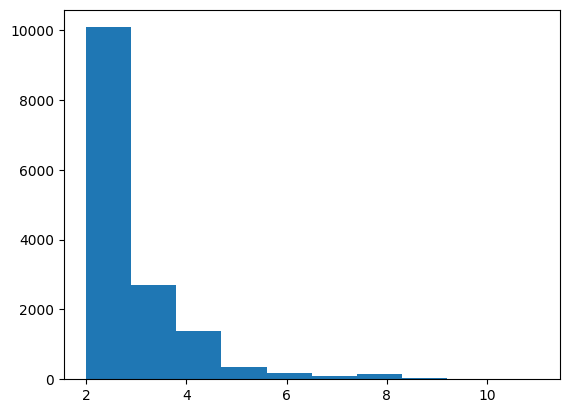

In [12]:
dist = [len(g) for k, g in df.groupby(['Member_number', 'Date'])]
plt.hist(dist)

In [13]:
def print_rules(rules):
    for rule in rules:
        print ('rule.items=', list(rule.items))
        print ('rule.support=',rule.support)

        for os in rule.ordered_statistics:
            print ('\titems_base=', list(os.items_base))
            print ('\tlifted_item =', list(os.items_add))
            print ('\tlift=', os.lift)
            print ('\tconfidence (i.e. cond prob {} if {})='.format(list(os.items_add), list(os.items_base)), os.confidence)
            print ('\n')
        
print_rules(rules)

rule.items= ['other vegetables']
rule.support= 0.3766033863519754
	items_base= []
	lifted_item = ['other vegetables']
	lift= 1.0
	confidence (i.e. cond prob ['other vegetables'] if [])= 0.3766033863519754


rule.items= ['rolls/buns']
rule.support= 0.3496664956387891
	items_base= []
	lifted_item = ['rolls/buns']
	lift= 1.0
	confidence (i.e. cond prob ['rolls/buns'] if [])= 0.3496664956387891


rule.items= ['soda']
rule.support= 0.3134940995382247
	items_base= []
	lifted_item = ['soda']
	lift= 1.0
	confidence (i.e. cond prob ['soda'] if [])= 0.3134940995382247


rule.items= ['whole milk']
rule.support= 0.4581836839404823
	items_base= []
	lifted_item = ['whole milk']
	lift= 1.0
	confidence (i.e. cond prob ['whole milk'] if [])= 0.4581836839404823


rule.items= ['Instant food products', 'rolls/buns']
rule.support= 0.00538737814263725
	items_base= ['Instant food products']
	lifted_item = ['rolls/buns']
	lift= 1.000953778429934
	confidence (i.e. cond prob ['rolls/buns'] if ['Instant food pro

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)




	items_base= ['soda', 'yogurt', 'sausage', 'bottled water', 'rolls/buns']
	lifted_item = ['other vegetables']
	lift= 1.689744860044588
	confidence (i.e. cond prob ['other vegetables'] if ['soda', 'yogurt', 'sausage', 'bottled water', 'rolls/buns'])= 0.6363636363636365


	items_base= ['soda', 'yogurt', 'other vegetables', 'sausage', 'rolls/buns']
	lifted_item = ['bottled water']
	lift= 2.259055346276442
	confidence (i.e. cond prob ['bottled water'] if ['soda', 'yogurt', 'other vegetables', 'sausage', 'rolls/buns'])= 0.4827586206896552


rule.items= ['other vegetables', 'whole milk', 'sausage', 'bottled water', 'white bread', 'rolls/buns']
rule.support= 0.002052334530528476
	items_base= ['bottled water', 'other vegetables', 'white bread', 'rolls/buns']
	lifted_item = ['sausage', 'whole milk']
	lift= 3.7390887290167862
	confidence (i.e. cond prob ['sausage', 'whole milk'] if ['bottled water', 'other vegetables', 'white bread', 'rolls/buns'])= 0.39999999999999997


	items_base= ['bottled 

In [14]:
def print_rules_multi_os(rules):
    for rule in rules:
        if len (rule.ordered_statistics)>1:  
            print ('rule.items=', list(rule.items))
            for os in rule.ordered_statistics:
                print ('\n\titems_base=', list(os.items_base))
                print ('\tlifted_item =', list(os.items_add))
                print ('\tlift=', os.lift)
                print ('\tconfidence (i.e. cond prob {} if {})='.format(list(os.items_add), list(os.items_base)), os.confidence)

            break 

print_rules_multi_os(rules)

rule.items= ['other vegetables', 'rolls/buns']

	items_base= ['other vegetables']
	lifted_item = ['rolls/buns']
	lift= 1.1143354637250336
	confidence (i.e. cond prob ['rolls/buns'] if ['other vegetables'])= 0.3896457765667575

	items_base= ['rolls/buns']
	lifted_item = ['other vegetables']
	lift= 1.1143354637250336
	confidence (i.e. cond prob ['other vegetables'] if ['rolls/buns'])= 0.41966250917094644


In [15]:
def parse_rules(rules):
    parsed_rules = []
    for rule in rules:
        for stat in rule.ordered_statistics:
            if len(stat.items_base) > 0:  
                parsed_rules.append({
                    'Base': tuple(stat.items_base),
                    'Add': tuple(stat.items_add),
                    'Support': rule.support,
                    'Confidence': stat.confidence,
                    'Lift': stat.lift
                })
    return pd.DataFrame(parsed_rules)

In [16]:
df_rules = parse_rules(rules)

In [17]:
df_rules['Score'] = df_rules['Lift']
top10 = df_rules.sort_values('Score', ascending=False).head(10)

In [18]:
print(top10[['Base', 'Add', 'Support', 'Confidence', 'Lift', 'Score']])

                                                    Base  \
98631                       (berries, pip fruit, yogurt)   
98644    (bottled water, other vegetables, yogurt, pork)   
98628                (berries, pip fruit, bottled water)   
98629                     (berries, bottled water, pork)   
98640     (berries, other vegetables, pip fruit, yogurt)   
98632                            (berries, yogurt, pork)   
98645           (bottled water, pip fruit, yogurt, pork)   
98643  (bottled water, other vegetables, pip fruit, p...   
98731            (bottled water, whole milk, soda, pork)   
84826  (citrus fruit, long life bakery product, whole...   

                                                Add   Support  Confidence  \
98631       (bottled water, other vegetables, pork)  0.002052    0.333333   
98644                          (berries, pip fruit)  0.002052    0.363636   
98628              (yogurt, other vegetables, pork)  0.002052    0.363636   
98629         (yogurt, other ve